# Trabalho Final - notebook base do projeto da Ana Manueli

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Pergunta de pesquisa

#### **Como o uso de ferramentas de IA está relacionado aos hábitos de estudo e ao desempenho dos estudantes?**

(produtividade, notas, participação)

--- Com o uso cada vez mais comum de ferramentas de IA generativa (ChatGPT e similares) por estudantes, é importante entender como esse uso se relaciona com a forma como eles estudam e com o resultado acadêmico que obtêm. Neste trabalho será utilizado o conjunto de dados *AI Student Impact Dataset*, com registros de 50.000 estudantes contendo quantas horas por semana cada um usa ferramentas de IA, para que finalidade, seu nível de habilidade em prompt engineering, quantas horas dedica ao estudo tradicional (sem IA), o GPA antes e depois do semestre e uma pontuação de retenção de habilidade. Pretende-se avaliar se **quanto** o estudante usa IA (e **como** usa) está associado a estudar mais ou menos da forma tradicional e a ter melhor ou pior desempenho acadêmico ao final do semestre — sem supor de antemão que "mais uso de IA" seja simplesmente bom ou ruim para o desempenho, já que o uso pode ser complementar ou substitutivo ao estudo tradicional.

In [2]:
# Carrega o dataset (zip contém 1 único CSV) e mostra as primeiras linhas
df = pd.read_csv("../datasets/ana_manueli/ai_student_impact_dataset.zip", compression='zip')

df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [3]:
# Lista todas as colunas disponíveis no dataset
df.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='str')

## Classificação das variáveis associadas à pergunta de pesquisa

In [4]:
# "Uso de ferramentas de IA" (quantidade) - Weekly_GenAI_Hours
df["Weekly_GenAI_Hours"].unique()

array([23.31,  1.12, 21.26, ..., 32.09, 35.33, 29.82], shape=(3566,))

O uso de ferramentas de IA, em quantidade, é medido por `Weekly_GenAI_Hours`, uma variável **numérica** (horas por semana) que varia de 0.0 a 40.0 no dataset.

In [5]:
# "Uso de ferramentas de IA" (finalidade) - Primary_Use_Case
df["Primary_Use_Case"].unique()

<StringArray>
[     'Copywriting/Drafting',                  'Ideation',
       'Summarizing_Reading', 'Debugging/Troubleshooting',
  'Direct_Answer_Generation']
Length: 5, dtype: str

A finalidade principal de uso da IA (`Primary_Use_Case`) é uma variável **categórica** e possui 5 categorias (ex.: redação/rascunho, geração de ideias, resumir leituras, depuração/resolução de problemas, geração de respostas diretas).

In [6]:
# "Uso de ferramentas de IA" (nível de habilidade) - Prompt_Engineering_Skill
df["Prompt_Engineering_Skill"].unique()

<StringArray>
['Beginner', 'Advanced', 'Intermediate']
Length: 3, dtype: str

O nível de habilidade em prompt engineering (`Prompt_Engineering_Skill`) é uma variável **categórica** e possui 3 categorias: Beginner, Intermediate e Advanced.

In [7]:
# "Hábitos de estudo" - Traditional_Study_Hours
df["Traditional_Study_Hours"].unique()

array([ 8.13, 16.65, 10.35, ..., 24.36, 26.87, 28.92], shape=(2516,))

Os hábitos de estudo são representados por `Traditional_Study_Hours`, uma variável **numérica** (horas de estudo tradicional, sem uso de IA, por semana) que varia de 1.0 a 35.86 no dataset.

In [8]:
# "Notas" (antes do semestre) - Pre_Semester_GPA
df["Pre_Semester_GPA"].unique()

array([2.418, 3.821, 3.398, ..., 1.688, 1.467, 2.027], shape=(2389,))

O GPA antes do semestre (`Pre_Semester_GPA`) é uma variável **numérica** que varia de 1.183 a 3.998 no dataset — consistente com a escala de GPA de 0 a 4.0 usada no sistema norte-americano, um padrão amplamente conhecido (não é uma hipótese: o próprio intervalo observado já cabe integralmente nessa escala).

In [9]:
# "Notas" (depois do semestre) - Post_Semester_GPA
df["Post_Semester_GPA"].unique()

array([2.393, 3.696, 3.499, ..., 1.923, 1.874, 1.715], shape=(2269,))

O GPA depois do semestre (`Post_Semester_GPA`) é uma variável **numérica**, na mesma escala de 0 a 4.0, e varia de 1.0 a 4.0 no dataset. É essa a variável usada para representar "notas" na pergunta de pesquisa, comparada ao GPA anterior para capturar variação ao longo do semestre.

In [10]:
# "Participação" (substituição) - Skill_Retention_Score
df["Skill_Retention_Score"].unique()

array([86.44, 69.39, 73.93, ..., 33.6 , 23.86, 98.57], shape=(5872,))

`Skill_Retention_Score` é uma variável **numérica** (pontuação de 0 a 100) e varia de 10.78 a 100.0 no dataset.

**Substituição de variável:** a pergunta de pesquisa pede "participação", mas o dataset não tem nenhuma coluna que meça participação em aula, frequência ou engajamento em atividades. A coluna mais próxima em significado é `Skill_Retention_Score`: ela mede o quanto o estudante reteve/consolidou a habilidade ao longo do semestre, o que é um reflexo indireto, mas plausível, de engajamento ativo com o conteúdo (quem participa mais tende a reter mais).

## Verificando a qualidade dos dados

In [11]:
# Verificando se há duplicatas
df.duplicated().sum()

np.int64(0)

In [12]:
# Se houver dados duplicados, verificamos quais são
df[df.duplicated()]

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level


**Conclusão 1:** não há nenhuma linha duplicada no dataset analisado (50.000 registros, 0 duplicatas).

In [13]:
# Verificando se há valores faltantes, em soma e em porcentagem, por coluna
dados_faltantes_soma = df.isnull().sum()
dados_faltantes_porc = df.isnull().mean() * 100

df_dados_faltantes = pd.DataFrame({"Dados faltantes (soma)": dados_faltantes_soma, "Dados faltantes (porcentagem)": dados_faltantes_porc})
df_dados_faltantes

,Dados faltantes (soma),Dados faltantes (porcentagem)
Student_ID,0,0.0
Major_Category,0,0.0
Year_of_Study,0,0.0
Pre_Semester_GPA,0,0.0
Weekly_GenAI_Hours,0,0.0
Primary_Use_Case,0,0.0
Prompt_Engineering_Skill,0,0.0
Tool_Diversity,0,0.0
Paid_Subscription,0,0.0
Traditional_Study_Hours,0,0.0


**Conclusão 2:** não há nenhum valor faltante em nenhuma das 16 colunas do dataset — todas têm 0 dados faltantes (0.0%). Isso inclui todas as variáveis usadas na pergunta de pesquisa (`Weekly_GenAI_Hours`, `Primary_Use_Case`, `Prompt_Engineering_Skill`, `Traditional_Study_Hours`, `Pre_Semester_GPA`, `Post_Semester_GPA`, `Skill_Retention_Score`), então não é preciso descartar nem imputar nenhuma linha por esse motivo.

## Limpeza do conjunto de dados

In [14]:
# Se houver duplicatas, remove a linha inteira que estiver duplicada
# (nenhuma foi encontrada na Conclusão 1, mas mantemos o passo por segurança/padrão)
df = df.drop_duplicates()

In [15]:
# As categorias de Primary_Use_Case misturam "/" e "_" como separador
# (ex.: "Copywriting/Drafting" vs "Summarizing_Reading" vs "Direct_Answer_Generation").
# Isso não gera categorias duplicadas (cada uma continua sendo um grupo distinto),
# mas deixa rótulos inconsistentes nas tabelas e no gráfico. Padronizamos trocando "_" por espaço.
df["Primary_Use_Case"] = df["Primary_Use_Case"].str.replace("_", " ", regex=False)

df["Primary_Use_Case"].value_counts()

Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing Reading           8633
Direct Answer Generation      6340
Name: count, dtype: int64

**Conclusão 3:** o dataset já chegou limpo em termos estruturais — sem duplicatas e sem dados faltantes (Conclusões 1 e 2), então não foi preciso descartar nenhuma linha. A única limpeza aplicada foi cosmética: padronizar o separador dos rótulos de `Primary_Use_Case` (trocando "_" por espaço), o que não muda o significado de nenhuma categoria, apenas a legibilidade nas tabelas e no gráfico. Como não há coluna com dado faltante entre as usadas na análise, não é preciso reconferir os dados faltantes depois da limpeza.

## Estatística descritiva

Utiliza as variáveis categóricas e numéricas identificadas no início do trabalho para calcular estatísticas descritivas pertinentes à pergunta de pesquisa.

In [ ]:
# "Weekly_GenAI_Hours" é numérica; para comparar grupos com groupby() precisamos
# transformá-la em faixas (variável categórica), assim como já fizemos com
# Primary_Use_Case e Prompt_Engineering_Skill (que já são categóricas).
#
# Não existe uma classificação de literatura/saúde pública para "horas semanais de uso
# de ferramentas de IA generativa por estudantes", então usamos quantis (pd.qcut),
# que dividem a amostra em grupos de tamanho aproximadamente igual.
#
# Antes de fixar o número de grupos, comparamos q=3, q=4 e q=5 para ver o trade-off
# entre granularidade (mais nuance) e tamanho de cada grupo (mais gente por grupo = média mais estável).
for q in [3, 4, 5]:
    faixas_teste, cortes_teste = pd.qcut(df["Weekly_GenAI_Hours"], q=q, retbins=True)
    print(f"q={q} | cortes: {cortes_teste.round(2).tolist()}")
    print(faixas_teste.value_counts().sort_index())
    print()

q=3 | cortes: [0.0, 3.38, 9.26, 40.0]
Weekly_GenAI_Hours
(-0.001, 3.38]    16694
(3.38, 9.26]      16642
(9.26, 40.0]      16664
Name: count, dtype: int64

q=4 | cortes: [0.0, 2.39, 5.8, 11.72, 40.0]
Weekly_GenAI_Hours
(-0.001, 2.39]    12510
(2.39, 5.8]       12516
(5.8, 11.72]      12479
(11.72, 40.0]     12495
Name: count, dtype: int64

q=5 | cortes: [0.0, 1.85, 4.25, 7.68, 13.59, 40.0]
Weekly_GenAI_Hours
(-0.001, 1.85]    10014
(1.85, 4.25]       9994
(4.25, 7.68]      10015
(7.68, 13.59]      9982
(13.59, 40.0]      9995
Name: count, dtype: int64



Com 50.000 estudantes, mesmo q=5 mantém grupos grandes e bem equilibrados (todos entre ~9.982 e ~10.015 pessoas), então o tamanho do grupo não é o fator decisivo aqui — os três valores de q são estatisticamente viáveis. A escolha foi por **q=3 (tercis)**: como não existe um padrão oficial de "baixo/médio/alto" para essa variável, tercis dão os rótulos mais simples e diretos de interpretar (Baixo/Médio/Alto), enquanto q=4 ou q=5 exigiriam rótulos intermediários mais artificiais (ex.: "médio-baixo", "médio-alto") sem nenhum ganho de interpretabilidade real, já que o corte em si continua sendo estatístico (por quantil), não baseado em um limiar com significado próprio.

In [17]:
# Aplica a divisão em tercis definida acima, mostrando os cortes numéricos (retbins=True)
# e o tamanho de cada grupo, para expor desbalanceamento (aqui não há: grupos ~1/3 cada)
df["Faixa_Uso_IA"], cortes_uso_ia = pd.qcut(
    df["Weekly_GenAI_Hours"], q=3, labels=["Baixo", "Medio", "Alto"], retbins=True
)

print("Cortes (horas semanais de uso de IA):", cortes_uso_ia.round(2).tolist())
print()
print(df["Faixa_Uso_IA"].value_counts().sort_index())

Cortes (horas semanais de uso de IA): [0.0, 3.38, 9.26, 40.0]

Faixa_Uso_IA
Baixo    16694
Medio    16642
Alto     16664
Name: count, dtype: int64


In [18]:
# Calcula a média de horas de estudo tradicional, GPA (antes/depois) e retenção de
# habilidade (proxy de participação) em cada faixa de uso de IA
outcomes = ["Traditional_Study_Hours", "Pre_Semester_GPA", "Post_Semester_GPA", "Skill_Retention_Score"]

df_med_uso_ia = df.groupby("Faixa_Uso_IA", observed=True)[outcomes].mean()

print("Média das variáveis de estudo/desempenho por faixa de uso de IA:")
print(df_med_uso_ia)

print("\n################################\n")

print("Maior média encontrada em cada variável:")
print(df_med_uso_ia.max())
print("\nFaixa de uso de IA correspondente à maior média:")
print(df_med_uso_ia.idxmax())

print("\n################################\n")

print("Menor média encontrada em cada variável:")
print(df_med_uso_ia.min())
print("\nFaixa de uso de IA correspondente à menor média:")
print(df_med_uso_ia.idxmin())

Média das variáveis de estudo/desempenho por faixa de uso de IA:
              Traditional_Study_Hours  Pre_Semester_GPA  Post_Semester_GPA  \
Faixa_Uso_IA                                                                 
Baixo                       11.870329          3.146993           3.337316   
Medio                       11.497815          3.144768           3.364052   
Alto                        10.258860          3.146543           3.346571   

              Skill_Retention_Score  
Faixa_Uso_IA                         
Baixo                     75.797235  
Medio                     76.849569  
Alto                      74.748961  

################################

Maior média encontrada em cada variável:
Traditional_Study_Hours    11.870329
Pre_Semester_GPA            3.146993
Post_Semester_GPA           3.364052
Skill_Retention_Score      76.849569
dtype: float64

Faixa de uso de IA correspondente à maior média:
Traditional_Study_Hours    Baixo
Pre_Semester_GPA           Baixo

In [19]:
# O grupo "Alto" uso de IA tem a MENOR média de Skill_Retention_Score, o que é
# contraintuitivo (esperava-se igual ou melhor retenção com mais uso de IA).
# Antes de concluir, investigamos quem compõe esse grupo: será que ele também
# concentra estudantes com maior risco de burnout, ou de um curso específico?
print("Risco de burnout (%) por faixa de uso de IA:")
print(pd.crosstab(df["Faixa_Uso_IA"], df["Burnout_Risk_Level"], normalize="index") * 100)

print("\n################################\n")

print("Área de estudo (%) por faixa de uso de IA:")
print(pd.crosstab(df["Faixa_Uso_IA"], df["Major_Category"], normalize="index") * 100)

Risco de burnout (%) por faixa de uso de IA:
Burnout_Risk_Level       High        Low     Medium
Faixa_Uso_IA                                       
Baixo                9.440518  48.736073  41.823410
Medio               16.662661  36.335777  47.001562
Alto                48.835814  13.118099  38.046087

################################

Área de estudo (%) por faixa de uso de IA:
Major_Category       Arts   Business  Humanities    Medical       STEM
Faixa_Uso_IA                                                          
Baixo           13.286211  25.038936   23.319756  14.130825  24.224272
Medio           12.234106  25.351520   21.235428  13.213556  27.965389
Alto            10.075612  24.837974   15.404465  11.509842  38.172108


**Conclusão 4:** dividindo o uso semanal de IA em tercis (Baixo: 0,0-3,38h; Médio: 3,38-9,26h; Alto: 9,26-40,0h — cada faixa com cerca de um terço da amostra, ~16.6-16.7 mil pessoas), o padrão não é uma reta simples:

- **Horas de estudo tradicional** caem de forma consistente conforme o uso de IA aumenta: 11,87h (Baixo) → 11,50h (Médio) → 10,26h (Alto), uma queda de cerca de 1,61h (~13,6%) entre os extremos. Isso é compatível com uso pelo menos parcialmente **substitutivo**: quem mais usa IA tende a estudar menos da forma tradicional.
- **GPA antes do semestre** é essencialmente igual nos três grupos (3,147 / 3,145 / 3,147) — um bom sinal de que os grupos não partem de níveis de desempenho diferentes; a diferença de uso de IA não reflete uma diferença prévia de capacidade acadêmica.
- **GPA depois do semestre** varia pouco entre os grupos (3,337 / 3,364 / 3,347): o grupo **Médio** tem a maior média, mas a diferença para os demais é pequena (no máximo ~0,027 pontos), não configurando uma relação clara de "mais uso = nota melhor ou pior".
- **Retenção de habilidade** (proxy de participação) também não é linear: 75,80 (Baixo) → 76,85 (Médio, a maior média) → 74,75 (Alto, a menor média). O grupo de uso **Alto** ter a pior retenção é contraintuitivo à primeira vista — mas investigando o grupo, o risco de burnout "Alto" salta de 9,44% (faixa Baixo) para 48,84% (faixa Alto), quase 5x mais. Ou seja, esse resultado provavelmente reflete, ao menos em parte, um **confundidor pelo nível de estresse/burnout**: o grupo de maior uso de IA concentra muito mais estudantes em risco alto de burnout, e não necessariamente um efeito direto do uso de IA sobre a retenção. Vale registrar também que a participação de estudantes de STEM sobe de 24,2% (Baixo) para 38,2% (Alto), então parte da composição por área de estudo também muda entre os grupos.

In [20]:
# Prompt_Engineering_Skill já é categórica; ordenamos as categorias para leitura mais
# natural (Beginner < Intermediate < Advanced) antes de calcular as médias
df["Prompt_Engineering_Skill"] = pd.Categorical(
    df["Prompt_Engineering_Skill"], categories=["Beginner", "Intermediate", "Advanced"], ordered=True
)

df_med_skill = df.groupby("Prompt_Engineering_Skill", observed=True)[outcomes].mean()

print("Média das variáveis de estudo/desempenho por nível de habilidade em prompt engineering:")
print(df_med_skill)

print("\n################################\n")

print("Maior média encontrada em cada variável:")
print(df_med_skill.max())
print("\nNível de habilidade correspondente à maior média:")
print(df_med_skill.idxmax())

print("\n################################\n")

print("Menor média encontrada em cada variável:")
print(df_med_skill.min())
print("\nNível de habilidade correspondente à menor média:")
print(df_med_skill.idxmin())

Média das variáveis de estudo/desempenho por nível de habilidade em prompt engineering:
                          Traditional_Study_Hours  Pre_Semester_GPA  \
Prompt_Engineering_Skill                                              
Beginner                                11.204303          3.149157   
Intermediate                            11.236899          3.147024   
Advanced                                11.180519          3.140830   

                          Post_Semester_GPA  Skill_Retention_Score  
Prompt_Engineering_Skill                                            
Beginner                           3.334401              71.101443  
Intermediate                       3.333948              75.824977  
Advanced                           3.388926              82.054186  

################################

Maior média encontrada em cada variável:
Traditional_Study_Hours    11.236899
Pre_Semester_GPA            3.149157
Post_Semester_GPA           3.388926
Skill_Retention_Score   

**Conclusão 5:** o nível de habilidade em prompt engineering separa os grupos de forma bem mais clara do que a quantidade de horas de uso de IA (Conclusão 4):

- **Horas de estudo tradicional** e **GPA antes do semestre** são praticamente iguais nos três níveis (11,18-11,24h; 3,141-3,149) — de novo, os grupos não partem de níveis de estudo ou capacidade prévia diferentes.
- **GPA depois do semestre** é mais alto no grupo **Advanced** (3,389) do que em Beginner (3,334) e Intermediate (3,334), uma diferença de cerca de 0,055 pontos (~1,6%) a favor de quem tem mais habilidade de prompt.
- **Retenção de habilidade** mostra a diferença mais forte de todo o notebook: 71,10 (Beginner) → 75,82 (Intermediate) → 82,05 (Advanced), uma diferença de quase 11 pontos (em uma escala de 0 a 100) entre iniciantes e avançados. Ou seja, **como** o estudante usa a IA (o quão bem ele formula os pedidos) parece estar associado ao desempenho de forma mais consistente do que **quanto** ele usa.

In [21]:
# Primary_Use_Case já é categórica (com rótulos padronizados na limpeza);
# calculamos as mesmas médias para ver se a FINALIDADE do uso de IA está associada
# a diferenças de estudo/desempenho
df_med_uso = df.groupby("Primary_Use_Case", observed=True)[outcomes].mean()

print("Média das variáveis de estudo/desempenho por finalidade principal de uso de IA:")
print(df_med_uso)

print("\n################################\n")

print("Maior média encontrada em cada variável:")
print(df_med_uso.max())
print("\nFinalidade de uso correspondente à maior média:")
print(df_med_uso.idxmax())

print("\n################################\n")

print("Menor média encontrada em cada variável:")
print(df_med_uso.min())
print("\nFinalidade de uso correspondente à menor média:")
print(df_med_uso.idxmin())

Média das variáveis de estudo/desempenho por finalidade principal de uso de IA:
                           Traditional_Study_Hours  Pre_Semester_GPA  \
Primary_Use_Case                                                       
Copywriting/Drafting                     11.313429          3.134880   
Debugging/Troubleshooting                11.124081          3.146712   
Direct Answer Generation                 11.217069          3.160691   
Ideation                                 11.142083          3.143755   
Summarizing Reading                      11.263396          3.153049   

                           Post_Semester_GPA  Skill_Retention_Score  
Primary_Use_Case                                                     
Copywriting/Drafting                3.335306              75.231097  
Debugging/Troubleshooting           3.395840              78.068964  
Direct Answer Generation            3.294164              73.718877  
Ideation                            3.343697              75.5202

**Conclusão 6:** a finalidade de uso da IA também está associada a diferenças, embora menores do que as da Conclusão 5:

- **Horas de estudo tradicional** variam pouco entre finalidades (11,12-11,31h) — não há uma finalidade claramente associada a mais ou menos estudo tradicional.
- **GPA depois do semestre** vai de 3,294 (Direct Answer Generation, a menor média) a 3,396 (Debugging/Troubleshooting, a maior), uma diferença de ~0,10 ponto (~3%).
- **Retenção de habilidade** vai de 73,72 (Direct Answer Generation, a menor média) a 78,07 (Debugging/Troubleshooting, a maior), uma diferença de ~4,35 pontos.

Em ambas as variáveis de desempenho, **Direct Answer Generation** (pedir a resposta pronta) é a finalidade com a pior média, e **Debugging/Troubleshooting** (usar a IA para resolver um problema específico) é a com a melhor. **Hipótese** (não confirmada diretamente pelos dados, que só mostram associação): usar a IA para obter respostas prontas tende a ser um uso mais passivo, com menos engajamento no raciocínio, enquanto depurar/resolver problemas exige mais interação e compreensão do próprio problema — o que poderia explicar a diferença. Não dá para descartar a direção causal oposta (estudantes com mais dificuldade recorrerem mais a respostas prontas), já que os dados são observacionais.

**Conclusão final de síntese:** juntando as três comparações, a resposta à pergunta de pesquisa é que o uso de ferramentas de IA está associado aos hábitos de estudo e ao desempenho dos estudantes, mas de forma diferente conforme o que se olha:

- **Quantidade de uso** (Conclusão 4): mais horas semanais de uso de IA estão associadas a **menos** horas de estudo tradicional (queda de ~1,61h entre os grupos Baixo e Alto), sugerindo um efeito ao menos parcialmente substitutivo. Já a relação com notas e com a retenção de habilidade (proxy de participação) **não é uma reta**: os melhores resultados de GPA e retenção aparecem no grupo de uso **Médio**, e o grupo de uso **Alto** tem a pior retenção — resultado que parece estar confundido pelo risco de burnout, muito mais frequente nesse grupo (48,84% vs 9,44% no grupo de uso Baixo), e não necessariamente causado pelo uso de IA em si.
- **Forma de uso** (Conclusões 5 e 6) parece pesar mais do que a quantidade: estudantes com habilidade **Advanced** em prompt engineering têm GPA final e retenção de habilidade claramente maiores do que Beginner/Intermediate (diferença de quase 11 pontos de retenção), e usar a IA para depuração/resolução de problemas está associado a notas e retenção mais altas do que usar para gerar respostas diretas.
- **Notas** (GPA) foram representadas diretamente pelas colunas do dataset; **participação** foi representada pela substituição declarada `Skill_Retention_Score`; **produtividade** não pôde ser representada — não há coluna nem proxy defensável no dataset para essa dimensão, e essa lacuna permanece explícita em vez de ter sido preenchida por uma equivalência inventada.

Em suma: **quanto** o estudante usa IA por si só não é um bom preditor de melhor desempenho nesta amostra (a relação é fraca e não-linear, e o grupo de maior uso carrega um confundidor de burnout); **como** o estudante usa a IA (nível de habilidade de prompt e finalidade de uso) está associado a diferenças mais consistentes de desempenho.

## Análise Exploratória

(apenas um "gostinho" no workshop de 29/08 pois isso será explorado no próximo encontro)

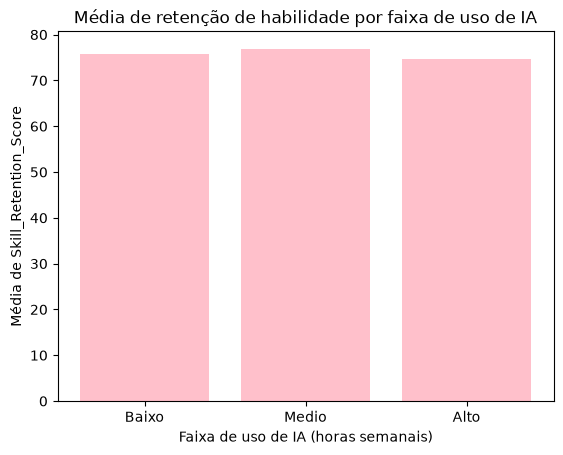

In [22]:
# gráfico de barras: retenção de habilidade média por faixa de uso de IA
# (mostra visualmente o padrão não-linear da Conclusão 4)
plt.bar(df_med_uso_ia.index, df_med_uso_ia["Skill_Retention_Score"], color="pink")
plt.title("Média de retenção de habilidade por faixa de uso de IA")
plt.xlabel("Faixa de uso de IA (horas semanais)")
plt.ylabel("Média de Skill_Retention_Score")
plt.show()

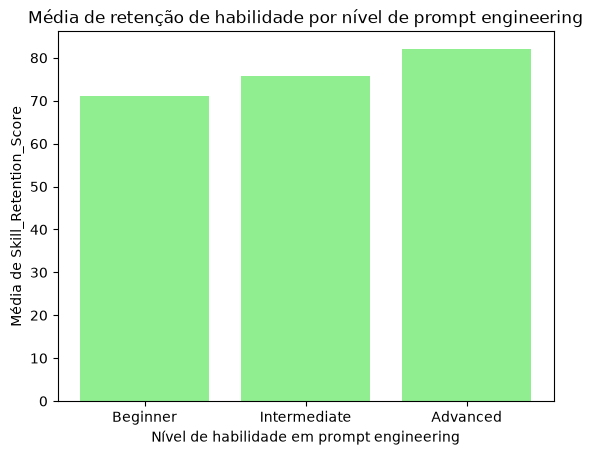

In [23]:
# gráfico de barras: retenção de habilidade média por nível de prompt engineering
# (mostra visualmente a relação mais forte e consistente da Conclusão 5)
plt.bar(df_med_skill.index.astype(str), df_med_skill["Skill_Retention_Score"], color="lightgreen")
plt.title("Média de retenção de habilidade por nível de prompt engineering")
plt.xlabel("Nível de habilidade em prompt engineering")
plt.ylabel("Média de Skill_Retention_Score")
plt.show()